<center>

# Particle Swarm Optimisation Algorithm

</center>

## Importing The Librarires

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

## Particle Swarm Optimization (PSO)

**Particle Swarm Optimization (PSO)** is a population-based stochastic optimization technique inspired by the social behavior of bird flocking or fish schooling. It is used to optimize a wide variety of continuous and discrete functions.

Each particle in the swarm represents a candidate solution and adjusts its position in the search space based on its own experience and the experience of neighboring particles.


## Mathematical Formulation

Let:
- $\vec{x}_i(t) \in \mathbb{R}^n$: position of the $i^\text{th}$ particle at iteration $t$
- $\vec{v}_i(t) \in \mathbb{R}^n$: velocity of the $i^\text{th}$ particle at iteration $t$
- $\vec{p}_i$: personal best position of particle $i$
- $\vec{g}$: global best position found by any particle in the swarm

The velocity and position update rules are:

### Velocity Update
$$
\vec{v}_i(t+1) = w \cdot \vec{v}_i(t) 
+ c_1 \cdot r_1 \cdot (\vec{p}_i - \vec{x}_i(t)) 
+ c_2 \cdot r_2 \cdot (\vec{g} - \vec{x}_i(t))
$$

### Position Update
$$
\vec{x}_i(t+1) = \vec{x}_i(t) + \vec{v}_i(t+1)
$$

Where:
- $w$: inertia weight (controls exploration vs. exploitation)
- $c_1$: cognitive coefficient (self-learning component)
- $c_2$: social coefficient (swarm influence)
- $r_1, r_2 \sim \mathcal{U}(0, 1)$: random numbers sampled independently for each dimension


## Objective

The goal is to minimize a cost (fitness) function:

$$
f: \mathbb{R}^n \rightarrow \mathbb{R}
$$

i.e., find:

$$
\vec{x}^* = \arg\min_{\vec{x} \in \mathbb{R}^n} f(\vec{x})
$$


## Algorithm Steps

1. **Initialize**:
   - Random positions $\vec{x}_i(0)$ and velocities $\vec{v}_i(0)$ for all particles
   - Evaluate initial fitness values

2. **Update**:
   - For each particle:
     - Evaluate the objective function at current position
     - Update personal best $\vec{p}_i$
     - Update global best $\vec{g}$

3. **Move**:
   - Update velocity $\vec{v}_i(t+1)$
   - Update position $\vec{x}_i(t+1)$

4. **Repeat** until max iterations or convergence.


## Parameters

| Parameter | Description |
|-----------|-------------|
| $w$ | Inertia weight (typically 0.4–0.9) |
| $c_1$ | Cognitive learning factor (e.g. 1.5–2.0) |
| $c_2$ | Social learning factor (e.g. 1.5–2.0) |
| $n$ | Dimensionality of the problem |
| $N$ | Number of particles in the swarm |


## Advantages

- Easy to implement
- Few parameters to tune
- Effective for continuous nonlinear optimization

## Limitations

- May get stuck in local minima
- Performance sensitive to parameter choices


In [2]:
class Particle:
    def __init__(self, dim, bounds):
        self.position = np.random.uniform(bounds[0], bounds[1], dim)
        self.velocity = np.random.uniform(-1, 1, dim)
        self.best_position = self.position.copy()
        self.best_value = float('inf')

class PSO:
    def __init__(self, func, dim, num_particles=30, bounds=(-5, 5),
                 w=0.7, c1=1.5, c2=1.5, max_iter=100):
        self.func = func
        self.dim = dim
        self.num_particles = num_particles
        self.bounds = bounds
        self.w = w         
        self.c1 = c1        
        self.c2 = c2        
        self.max_iter = max_iter

        self.swarm = [Particle(dim, bounds) for _ in range(num_particles)]
        self.gbest_position = np.random.uniform(bounds[0], bounds[1], dim)
        self.gbest_value = float('inf')
        self.gbest_value_history = []
        self.gbest_history = []
        self.positions_history = []

    def optimize(self):
        for iter in range(self.max_iter):
            current_positions = []

            for particle in self.swarm:
                fitness = self.func(particle.position)

                if fitness < particle.best_value:
                    particle.best_value = fitness
                    particle.best_position = particle.position.copy()

                if fitness < self.gbest_value:
                    self.gbest_value = fitness
                    self.gbest_position = particle.position.copy()

                current_positions.append(particle.position.copy())

            self.positions_history.append(current_positions)
            self.gbest_history.append(self.gbest_position.copy())
            self.gbest_value_history.append(self.gbest_value)

            for particle in self.swarm:
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                cognitive = self.c1 * r1 * (particle.best_position - particle.position)
                social = self.c2 * r2 * (self.gbest_position - particle.position)

                particle.velocity = self.w * particle.velocity + cognitive + social
                particle.position += particle.velocity

                particle.position = np.clip(particle.position, self.bounds[0], self.bounds[1])

        return self.gbest_position, self.gbest_value

    def get_gbest_history(self):
        return self.gbest_history
    
    def get_gbest_value_history(self):
        return self.gbest_value_history

    def get_positions_history(self):
        return self.positions_history


## Tested Benchmark Functions

1. **Rastrigin Function**:

   $$
   f(\vec{x}) = An + \sum_{i=1}^{n} \left[ x_i^2 - A \cos(2\pi x_i) \right], \quad A = 10
   $$

   * Minimum at $\vec{x} = \vec{0}$, $f(\vec{0}) = 0$

2. **Ackley Function**:

   $$
   f(\vec{x}) = -a \exp\left( -b \sqrt{\frac{1}{n} \sum x_i^2} \right) - \exp\left( \frac{1}{n} \sum \cos(c x_i) \right) + a + e
   $$

   * Common values: $a = 20$, $b = 0.2$, $c = 2\pi$
   * Global minimum at $\vec{x} = \vec{0}$, $f(\vec{0}) = 0$

3. **Rosenbrock Function**:

   $$
   f(\vec{x}) = \sum_{i=1}^{n-1} \left[100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2\right]
   $$

   * Minimum at $\vec{x} = [1, ..., 1]$, $f(\vec{x}) = 0$

4. **Sphere Function**:

   $$
   f(\vec{x}) = \sum_{i=1}^{n} x_i^2
   $$

   * Global minimum at $\vec{x} = \vec{0}$, $f(\vec{0}) = 0$
   * Simple convex quadratic bowl; commonly used as a baseline function


In [3]:
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    A = 10
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

def ackley(x):
    a = 20
    b = 0.2
    c = 2 * np.pi
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(c * x))
    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + a + np.exp(1)

def rosenbrock(x):
    return np.sum(100 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

In [4]:
func = sphere
pso = PSO(func=func, dim=3, num_particles=50, max_iter=200, bounds=(-5.12, 5.12))
gbest_pos, gbest_val = pso.optimize()

print(f"\nSphere : ")
print("Best position:", gbest_pos)
print("Best value:", gbest_val)

func = rastrigin
pso = PSO(func=func, dim=3, num_particles=50, max_iter=200, bounds=(-5.12, 5.12))
gbest_pos, gbest_val = pso.optimize()

print(f"\nRastrigin : ")
print("Best position:", gbest_pos)
print("Best value:", gbest_val)

func = ackley
pso = PSO(func=func, dim=3, num_particles=50, max_iter=200, bounds=(-5.12, 5.12))
gbest_pos, gbest_val = pso.optimize()

print(f"\nAckley : ")
print("Best position:", gbest_pos)
print("Best value:", gbest_val)

func = rosenbrock
pso = PSO(func=func, dim=3, num_particles=50, max_iter=200, bounds=(-5.12, 5.12))
gbest_pos, gbest_val = pso.optimize()

print(f"\nRosenbrock : ")
print("Best position:", gbest_pos)
print("Best value:", gbest_val)


Sphere : 
Best position: [-1.63684710e-12  3.05887165e-11  2.10217549e-11]
Best value: 1.380263026356933e-21

Rastrigin : 
Best position: [ 3.04659254e-09  1.59167524e-09 -6.30199310e-09]
Best value: 7.105427357601002e-15

Ackley : 
Best position: [ 1.10662236e-11  5.76944665e-12 -2.00162892e-11]
Best value: 5.447420292625793e-11

Rosenbrock : 
Best position: [0.97830442 0.95744264 0.91690887]
Best value: 0.00229952632365532


## Funtions For 3D Plots

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
dpi = 100
def plot_function_surface(func, bounds=(-5.12, 5.12), title="Function Surface", c="Blues"):
    fig = plt.figure(figsize=(10, 10), dpi=dpi)
    ax = fig.add_subplot(111, projection='3d')

    X = np.linspace(bounds[0], bounds[1], 200)
    Y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(X, Y)
    Z = np.array([func(np.array([x, y])) for x, y in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

    ax.plot_surface(X, Y, Z, cmap=c, alpha=0.8, edgecolor='none')
    ax.set_title(title, fontsize=16, weight="bold")
    ax.set_xlabel("x", fontsize=12, weight="bold")
    ax.set_ylabel("y", fontsize=12, weight="bold")
    ax.set_zlabel("f(x, y)", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

def plot_convergence(gbest_value_history, c="black"):
    values = gbest_value_history
    plt.figure(figsize=(10, 10), dpi=dpi)
    plt.plot(values, color=c, label='Global Best Value')
    plt.axhline(y=0, color='black', linewidth=1)  # X-axis line
    plt.axvline(x=0, color='black', linewidth=1)  # Y-axis line
    plt.xlabel("Iterations", fontsize=12, weight="bold")
    plt.ylabel("f(Global Best)", fontsize=12, weight="bold")
    plt.title("Convergence Over Iterations", fontsize=16, weight="bold")
    plt.grid(linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_gbest_contour(pso, func, bounds=(-5.12, 5.12), title="GBest Path on Contour", c="cubehelix"):
    x = np.linspace(bounds[0], bounds[1], 400)
    y = np.linspace(bounds[0], bounds[1], 400)
    X, Y = np.meshgrid(x, y)
    Z = np.array([func(np.array([xi, yi])) for xi, yi in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

    plt.figure(figsize=(10, 10), dpi=dpi)
    contour = plt.contourf(X, Y, Z, levels=100, cmap=c, alpha=0.8)
    plt.colorbar(contour)

    gbest_path = np.array(pso.get_gbest_history())
    if gbest_path.shape[1] >= 2:
        plt.plot(gbest_path[:, 0], gbest_path[:, 1], marker='o', color='darkblue', linestyle="--", linewidth=2, label='Global Best Path')
        plt.scatter(gbest_path[-1, 0], gbest_path[-1, 1], color='cyan', edgecolors='black', zorder=5, label='Final GBest')
    else:
        print("Error: Global best path is not 2D — this plot is only for dim=2.")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

### Rastrigin function

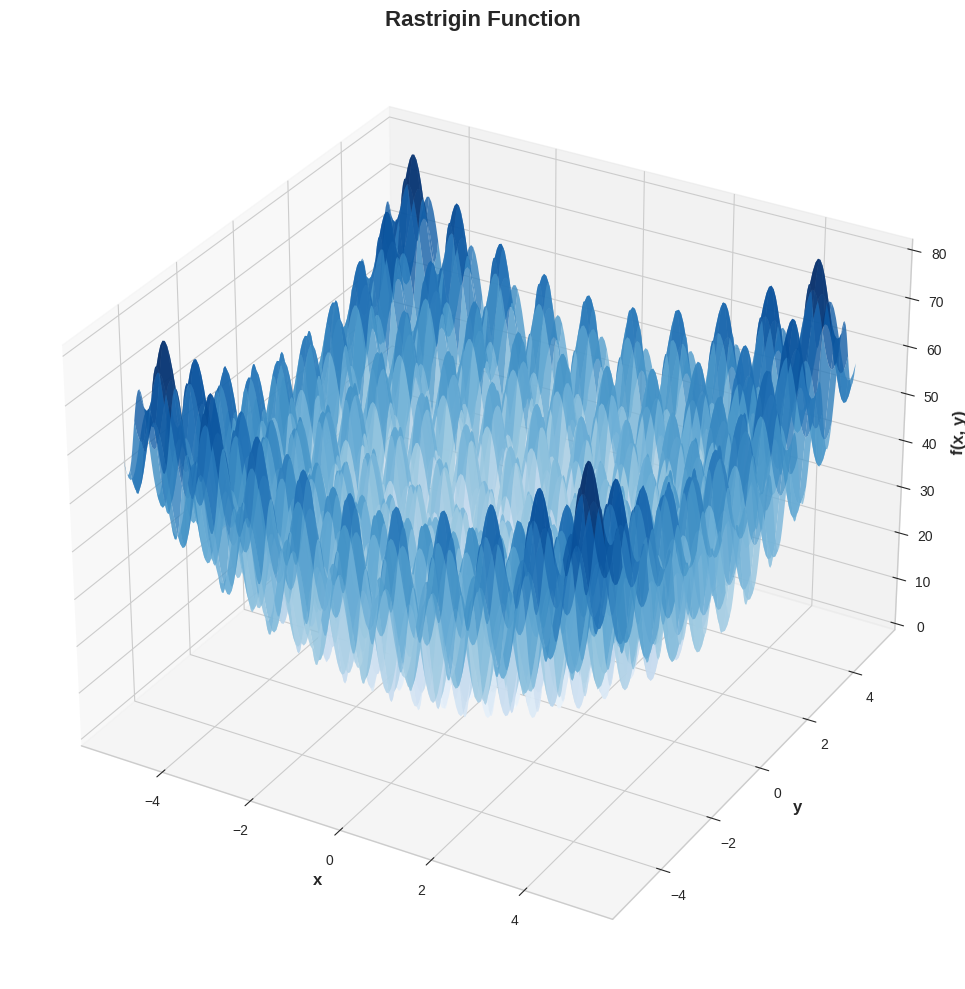

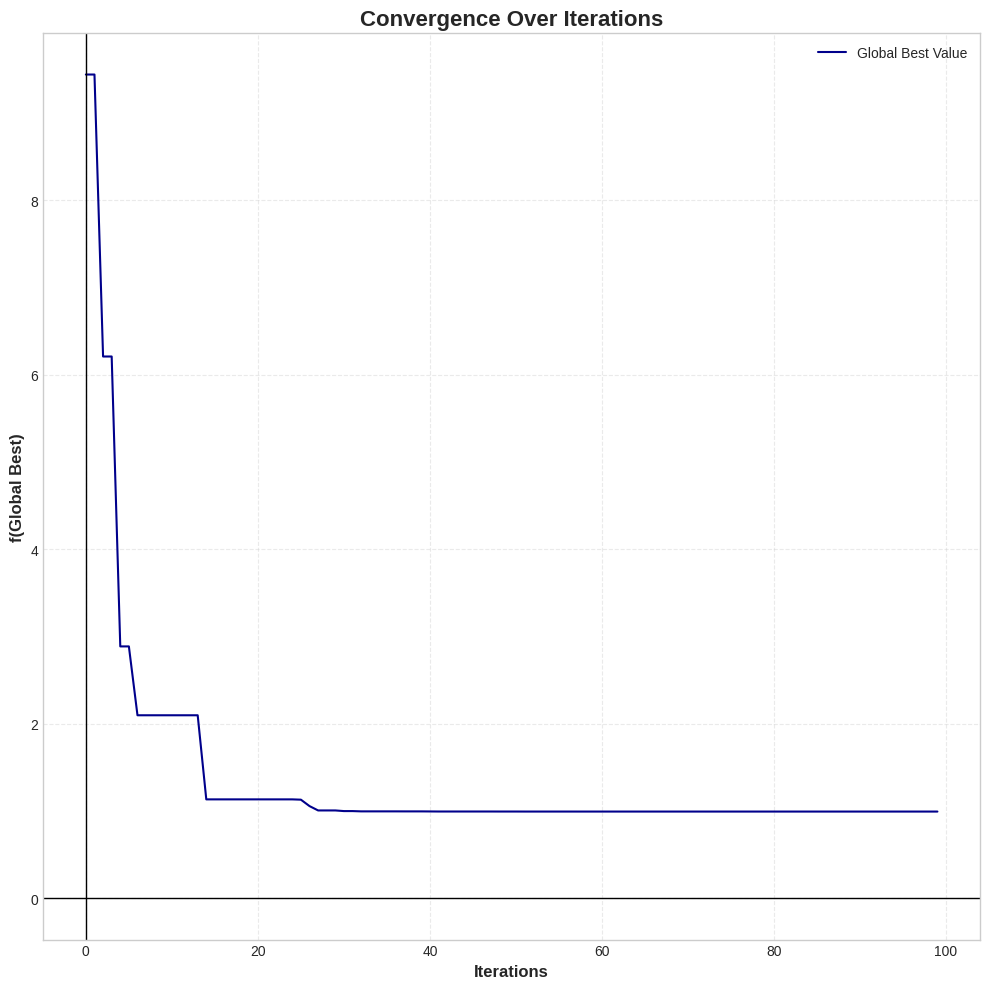

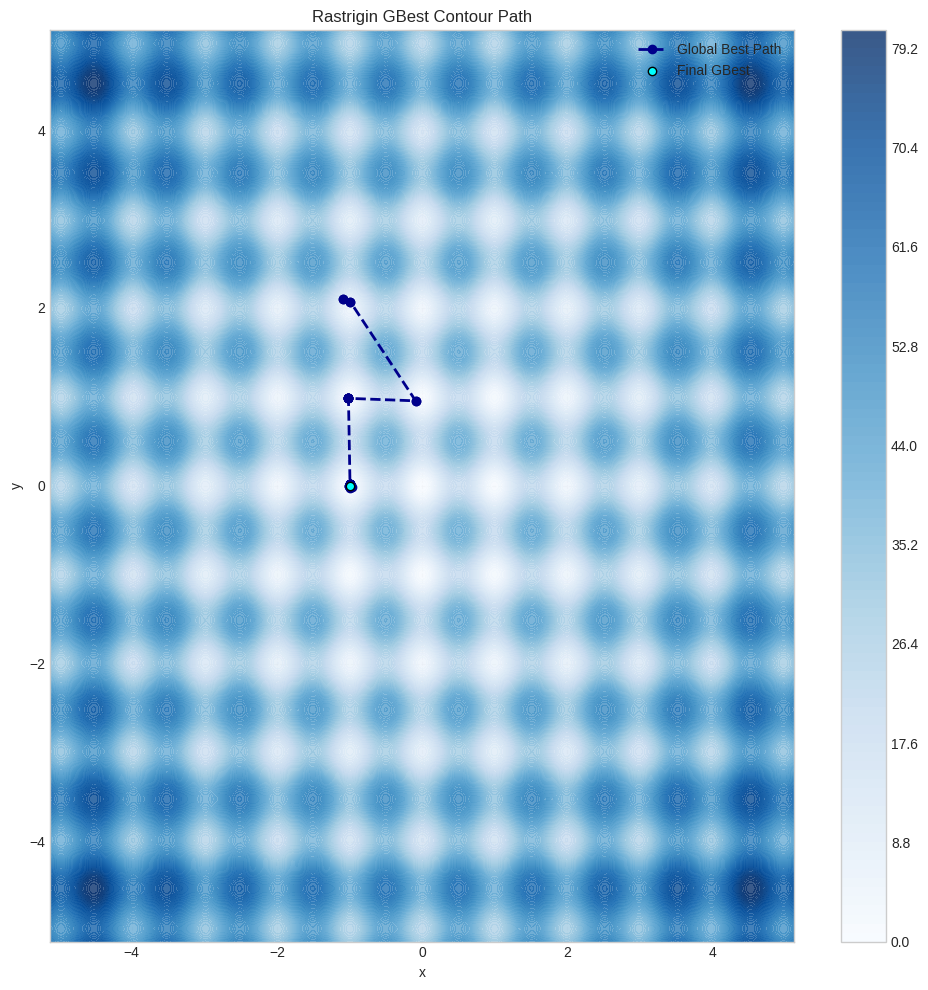

In [6]:
func = rastrigin
bounds = (-5.12, 5.12)

plot_function_surface(func, bounds=bounds, title="Rastrigin Function", c="Blues")

pso = PSO(func=func, dim=2, num_particles=10, max_iter=100, bounds=bounds)
gbest_pos, gbest_val = pso.optimize()
plot_convergence(pso.get_gbest_value_history(), c="darkblue")
plot_gbest_contour(pso, func=func, bounds=(-5.12, 5.12), title="Rastrigin GBest Contour Path", c="Blues")

### Ackley Function

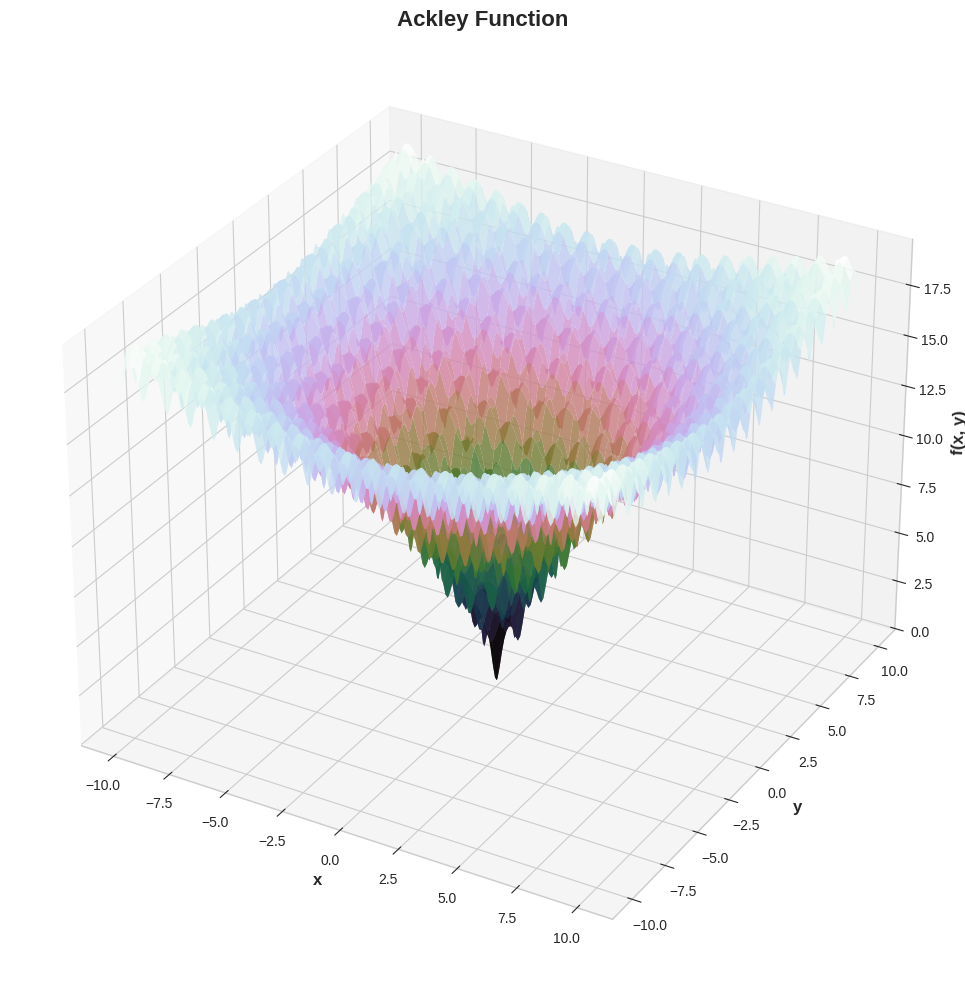

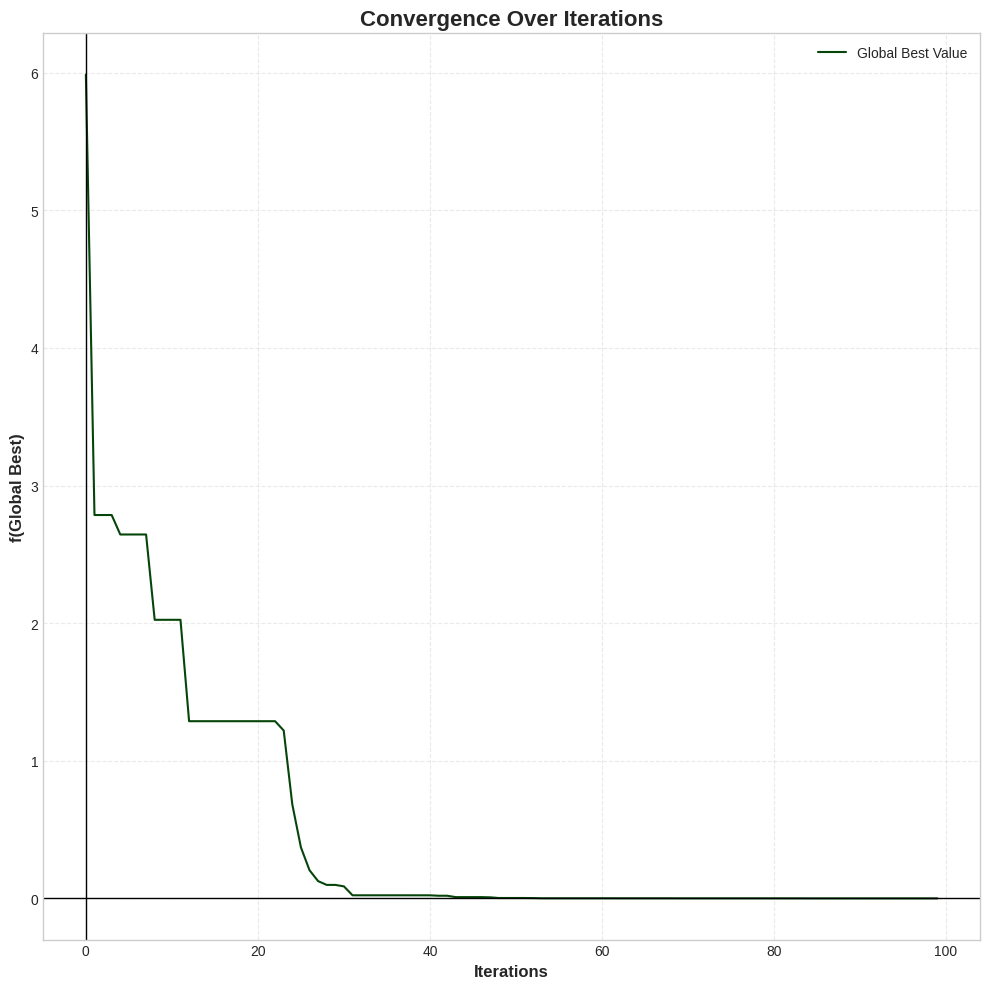

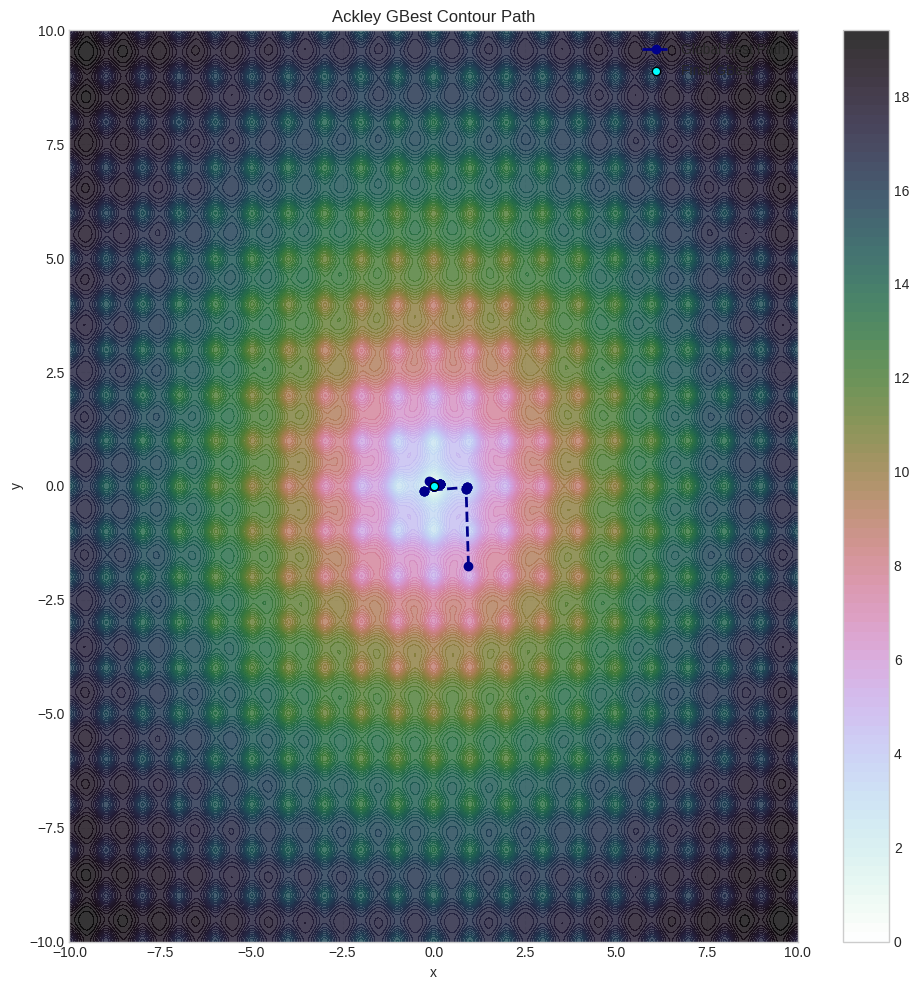

In [7]:
func = ackley
bounds = (-10, 10)

plot_function_surface(func, bounds=bounds, title="Ackley Function", c="cubehelix")

pso = PSO(func=func, dim=2, num_particles=10, max_iter=100, bounds=bounds)
gbest_pos, gbest_val = pso.optimize()
plot_convergence(pso.get_gbest_value_history(), c="#064509")
plot_gbest_contour(pso, func=func, bounds=(-10, 10), title="Ackley GBest Contour Path", c="cubehelix_r")

### Sphere Function

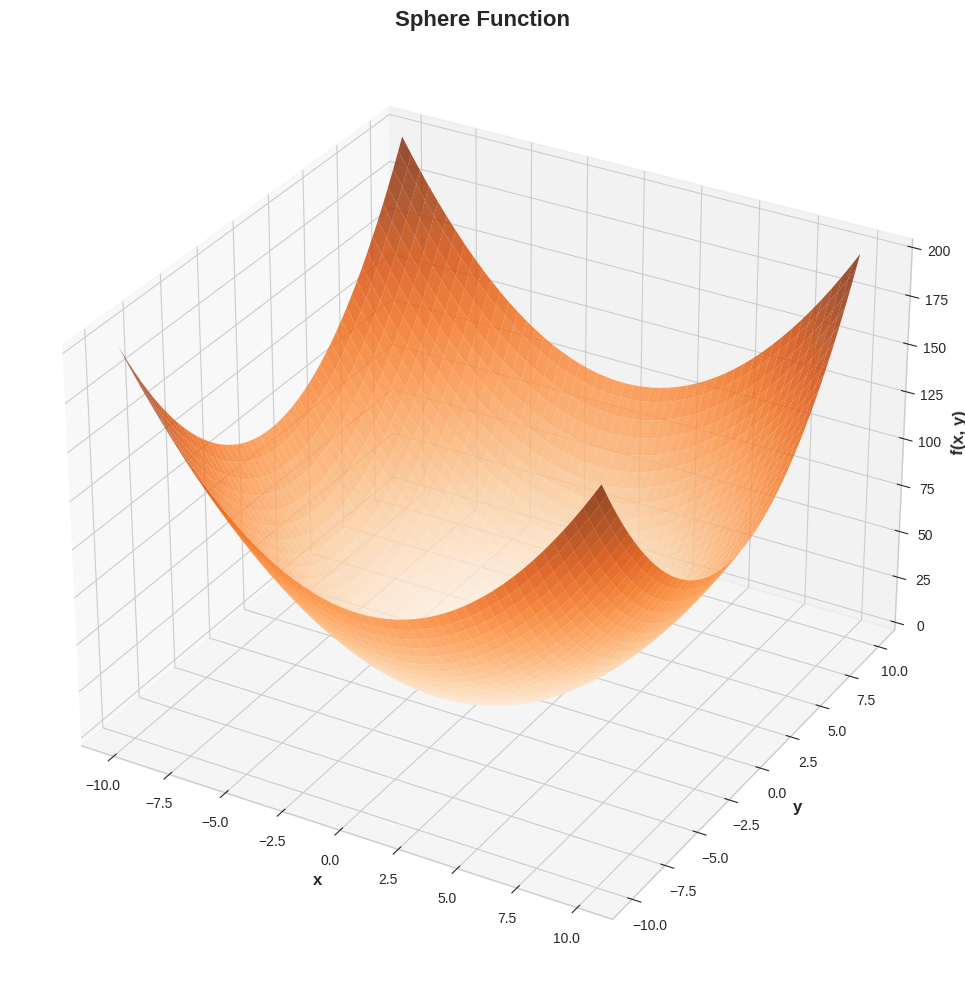

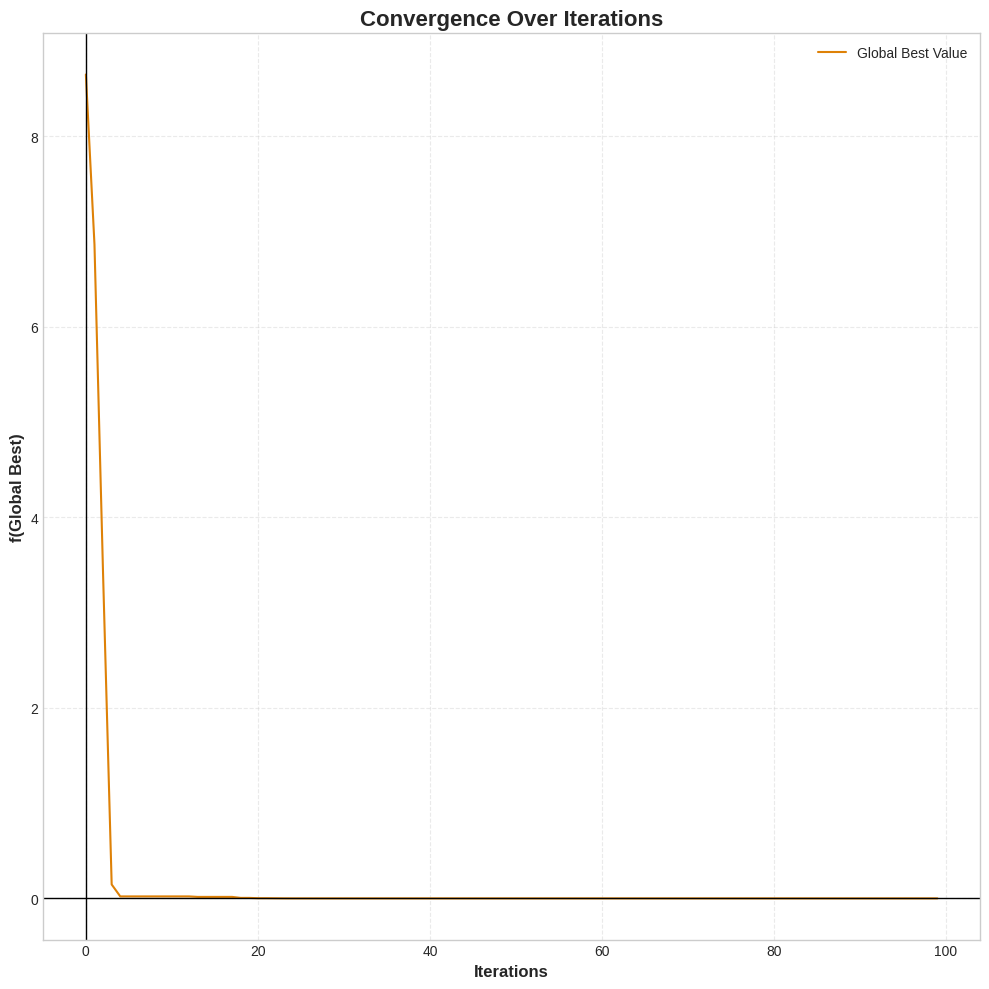

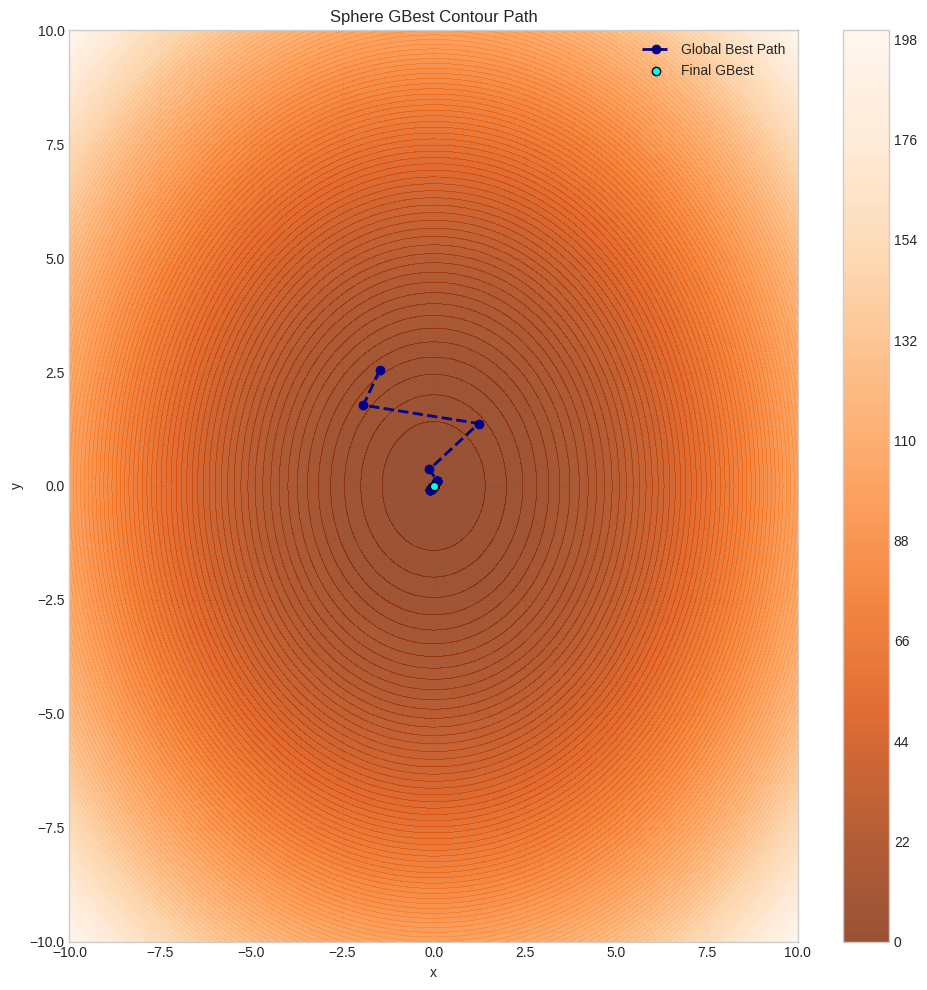

In [8]:
func = sphere
bounds = (-10, 10)

plot_function_surface(func, bounds=bounds, title="Sphere Function", c="Oranges")

pso = PSO(func=func, dim=2, num_particles=10, max_iter=100, bounds=bounds)
gbest_pos, gbest_val = pso.optimize()
plot_convergence(pso.get_gbest_value_history(), c="#de8107")
plot_gbest_contour(pso, func=func, bounds=(-10, 10), title="Sphere GBest Contour Path", c="Oranges_r")

### Rosenbrock Function

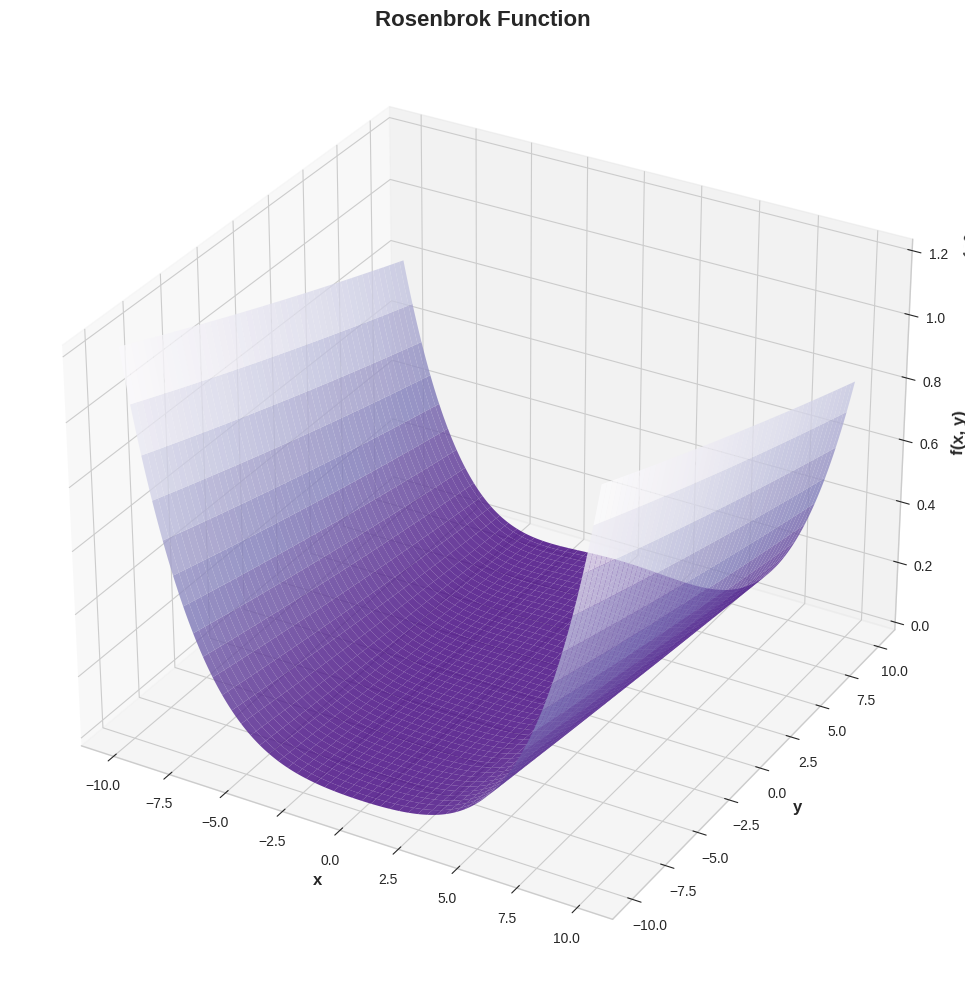

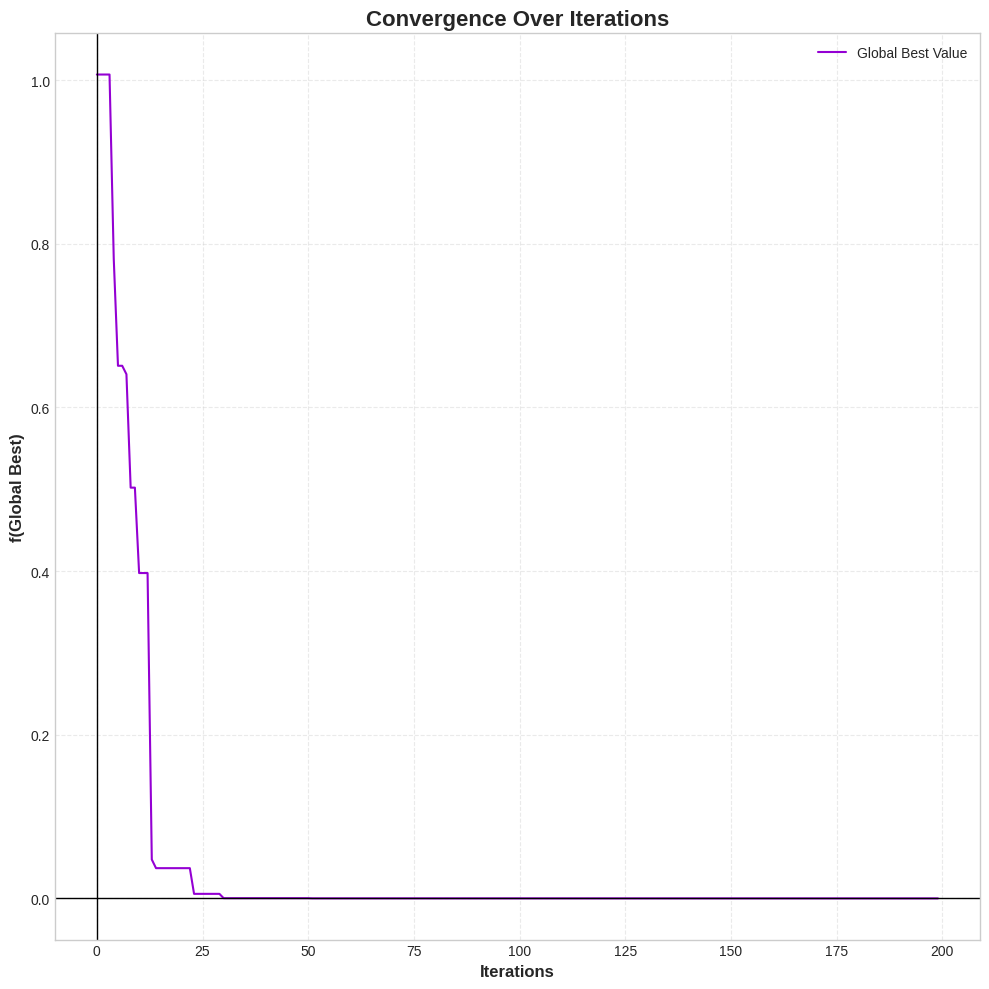

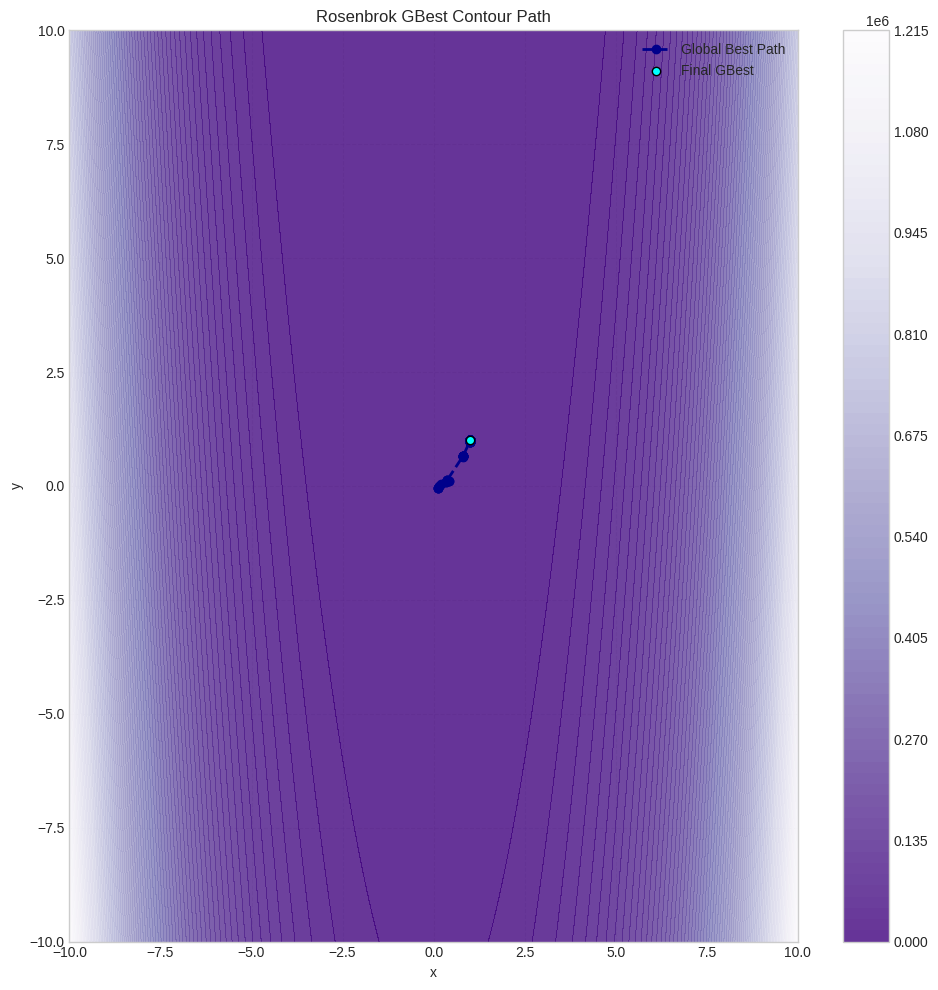

In [9]:
func = rosenbrock
bounds = (-10, 10)

plot_function_surface(func, bounds=bounds, title="Rosenbrok Function", c="Purples_r")

pso = PSO(func=func, dim=2, num_particles=20, max_iter=200, bounds=bounds)
gbest_pos, gbest_val = pso.optimize()
plot_convergence(pso.get_gbest_value_history(), c="darkviolet")
plot_gbest_contour(pso, func=func, bounds=(-10, 10), title="Rosenbrok GBest Contour Path", c="Purples_r")

## References

- Kennedy, J., & Eberhart, R. (1995). *Particle swarm optimization*. Proceedings of ICNN'95 - International Conference on Neural Networks.
- Engelbrecht, A. P. (2007). *Computational Intelligence: An Introduction*. Wiley.